# Proyek Analisis Data: Kualitas Udara Stasiun Tiantan

- **Nama:** [Lengkapi Nama Anda]
- **Email:** [Lengkapi Email Anda]
- **ID Dicoding:** [Lengkapi ID Dicoding Anda]

Notebook ini dibuat untuk submission Dicoding Proyek Analisis Data. Dataset yang digunakan adalah **PRSA_Data_Tiantan_20130301-20170228.csv**, yaitu data kualitas udara per jam di Stasiun Tiantan, Beijing, selama periode 1 Maret 2013 sampai 28 Februari 2017.


## Menentukan Pertanyaan Bisnis

Pertanyaan bisnis dibuat dengan prinsip SMART: spesifik, terukur, relevan, dapat ditindaklanjuti, dan memiliki batas waktu berdasarkan periode data 2013-2017.


1. **Bagaimana tren rata-rata bulanan PM2.5 di Stasiun Tiantan selama periode Maret 2013 hingga Februari 2017?**
2. **Pada musim apa tingkat polusi PM2.5 dan PM10 cenderung paling tinggi di Stasiun Tiantan selama periode Maret 2013 hingga Februari 2017?**
3. **Bagaimana hubungan antara kecepatan angin dan konsentrasi PM2.5 di Stasiun Tiantan selama periode Maret 2013 hingga Februari 2017?**


## Import Semua Packages/Library yang Digunakan


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 50)


## Data Wrangling


### Gathering Data

Tahap ini memuat dataset mentah dari folder `data`, menampilkan beberapa baris awal, dan melihat ukuran dataset.


In [2]:
DATA_FILENAME = "PRSA_Data_Tiantan_20130301-20170228.csv"
current_dir = Path.cwd()

if (current_dir / "data" / DATA_FILENAME).exists():
    PROJECT_DIR = current_dir
elif (current_dir / "submission" / "data" / DATA_FILENAME).exists():
    PROJECT_DIR = current_dir / "submission"
else:
    raise FileNotFoundError("Dataset tidak ditemukan. Pastikan struktur folder submission sudah sesuai.")

DATA_PATH = PROJECT_DIR / "data" / DATA_FILENAME
DASHBOARD_DIR = PROJECT_DIR / "dashboard"
MAIN_DATA_PATH = DASHBOARD_DIR / "main_data.csv"

raw_df = pd.read_csv(DATA_PATH)
raw_df.head()


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,6.0,4.0,8.0,300.0,81.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Tiantan
1,2,2013,3,1,1,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Tiantan
2,3,2013,3,1,2,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Tiantan
3,4,2013,3,1,3,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,N,4.9,Tiantan
4,5,2013,3,1,4,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Tiantan


In [3]:
print(f"Ukuran dataset: {raw_df.shape[0]:,} baris dan {raw_df.shape[1]:,} kolom")
print(f"Stasiun: {', '.join(raw_df['station'].unique())}")
print(f"Periode tahun: {raw_df['year'].min()} sampai {raw_df['year'].max()}")


Ukuran dataset: 35,064 baris dan 18 kolom
Stasiun: Tiantan
Periode tahun: 2013 sampai 2017


**Insight:**

Dataset ini berisi data kualitas udara per jam di Stasiun Tiantan. Kolom waktu masih dipisah menjadi `year`, `month`, `day`, dan `hour`. Kolom polutan utama meliputi PM2.5, PM10, SO2, NO2, CO, dan O3, sedangkan variabel cuaca meliputi TEMP, PRES, DEWP, RAIN, wd, dan WSPM.


### Assessing Data

Tahap ini memeriksa struktur data, missing value, duplikasi, tipe data, statistik deskriptif, serta nilai unik pada kolom penting.


In [4]:
raw_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34387 non-null  float64
 6   PM10     34467 non-null  float64
 7   SO2      33946 non-null  float64
 8   NO2      34320 non-null  float64
 9   CO       33938 non-null  float64
 10  O3       34221 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34986 non-null  str    
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  str    
dtypes: float64(11), int64(5), str(2)
memory usage: 5.1 MB


In [5]:
raw_df.isna().sum().sort_values(ascending=False)


CO         1126
SO2        1118
O3          843
NO2         744
PM2.5       677
PM10        597
wd           78
RAIN         20
DEWP         20
PRES         20
TEMP         20
WSPM         14
year          0
No            0
day           0
month         0
hour          0
station       0
dtype: int64

In [6]:
print(f"Jumlah data duplikat: {raw_df.duplicated().sum()}")


Jumlah data duplikat: 0


In [7]:
raw_df.dtypes


No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd             str
WSPM       float64
station        str
dtype: object

In [8]:
raw_df.describe().round(2)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.00,35064.00,35064.00,35064.00,35064.00,34387.00,34467.00,33946.00,34320.00,33938.00,34221.00,35044.00,35044.00,35044.00,35044.00,35050.00
mean,17532.50,2014.66,6.52,15.73,11.50,82.16,106.36,14.37,53.16,1298.30,55.98,13.67,1012.55,2.45,0.06,1.86
std,10122.25,1.18,3.45,8.80,6.92,80.92,89.70,20.14,31.95,1170.59,59.08,11.46,10.27,13.81,0.79,1.28
min,1.00,2013.00,1.00,1.00,0.00,3.00,2.00,0.57,2.00,100.00,0.43,-16.80,987.10,-35.30,0.00,0.00
25%,8766.75,2014.00,4.00,8.00,5.75,22.00,41.00,3.00,28.00,500.00,8.00,3.10,1004.00,-8.80,0.00,1.00
50%,17532.50,2015.00,7.00,16.00,11.50,59.00,85.00,7.00,47.00,900.00,40.00,14.60,1012.20,3.00,0.00,1.50
75%,26298.25,2016.00,10.00,23.00,17.25,113.00,144.00,17.00,71.00,1600.00,81.00,23.50,1020.90,15.00,0.00,2.40
max,35064.00,2017.00,12.00,31.00,23.00,821.00,988.00,273.00,241.00,10000.00,674.00,41.10,1042.00,28.80,46.40,10.50


In [9]:
print("Nilai unik station:")
print(raw_df["station"].unique())

print("Jumlah nilai unik wd:")
print(raw_df["wd"].nunique())

print("Contoh nilai wd:")
print(raw_df["wd"].dropna().unique()[:10])


Nilai unik station:
<ArrowStringArray>
['Tiantan']
Length: 1, dtype: str
Jumlah nilai unik wd:
16
Contoh nilai wd:
<ArrowStringArray>
['NNW', 'NW', 'N', 'W', 'ENE', 'NE', 'E', 'NNE', 'SW', 'SSW']
Length: 10, dtype: str


**Masalah data yang ditemukan:**

1. Terdapat missing value pada beberapa kolom polutan dan cuaca, seperti PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, wd, dan WSPM.
2. Kolom tanggal dan waktu masih terpisah menjadi `year`, `month`, `day`, dan `hour`, sehingga perlu digabung menjadi kolom `datetime`.
3. Kolom `wd` merupakan data kategorikal arah angin dan memiliki missing value, sehingga tidak tepat jika diisi dengan interpolasi numerik.
4. Beberapa kolom polutan memiliki rentang nilai yang lebar, misalnya CO dan PM10, sehingga perlu berhati-hati ketika divisualisasikan dalam satu grafik.


### Cleaning Data

Tahap cleaning dilakukan dengan membuat salinan data, membentuk kolom `datetime`, menangani missing value, membuat kolom pendukung, dan menyimpan data bersih untuk dashboard.


In [10]:
clean_df = raw_df.copy()

clean_df["datetime"] = pd.to_datetime(clean_df[["year", "month", "day", "hour"]])
clean_df = clean_df.sort_values("datetime").drop_duplicates().reset_index(drop=True)

numeric_columns = clean_df.select_dtypes(include=[np.number]).columns
clean_df = clean_df.set_index("datetime")
clean_df[numeric_columns] = clean_df[numeric_columns].interpolate(method="time", limit_direction="both")
clean_df[numeric_columns] = clean_df[numeric_columns].fillna(clean_df[numeric_columns].median(numeric_only=True))

clean_df["wd"] = clean_df["wd"].fillna(clean_df["wd"].mode()[0])
clean_df = clean_df.reset_index()

clean_df["date"] = clean_df["datetime"].dt.date.astype(str)
clean_df["year"] = clean_df["datetime"].dt.year
clean_df["month"] = clean_df["datetime"].dt.month
clean_df["month_name"] = clean_df["datetime"].dt.month_name()
clean_df["month_year"] = clean_df["datetime"].dt.to_period("M").astype(str)

season_map = {
    3: "Musim Semi", 4: "Musim Semi", 5: "Musim Semi",
    6: "Musim Panas", 7: "Musim Panas", 8: "Musim Panas",
    9: "Musim Gugur", 10: "Musim Gugur", 11: "Musim Gugur",
    12: "Musim Dingin", 1: "Musim Dingin", 2: "Musim Dingin",
}
clean_df["season"] = clean_df["month"].map(season_map)

clean_df.head()


,datetime,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,date,month_name,month_year,season
0,2013-03-01 00:00:00,1,2013,3,1,0,6.0,6.0,4.0,8.0,300.0,81.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Tiantan,2013-03-01,March,2013-03,Musim Semi
1,2013-03-01 01:00:00,2,2013,3,1,1,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Tiantan,2013-03-01,March,2013-03,Musim Semi
2,2013-03-01 02:00:00,3,2013,3,1,2,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Tiantan,2013-03-01,March,2013-03,Musim Semi
3,2013-03-01 03:00:00,4,2013,3,1,3,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,N,4.9,Tiantan,2013-03-01,March,2013-03,Musim Semi
4,2013-03-01 04:00:00,5,2013,3,1,4,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Tiantan,2013-03-01,March,2013-03,Musim Semi


In [11]:
print(f"Total missing value setelah cleaning: {clean_df.isna().sum().sum()}")
print(f"Jumlah data duplikat setelah cleaning: {clean_df.duplicated().sum()}")
print(f"Tipe data datetime: {clean_df['datetime'].dtype}")
print(f"Rentang waktu: {clean_df['datetime'].min()} sampai {clean_df['datetime'].max()}")


Total missing value setelah cleaning: 0
Jumlah data duplikat setelah cleaning: 0
Tipe data datetime: datetime64[us]
Rentang waktu: 2013-03-01 00:00:00 sampai 2017-02-28 23:00:00


#### Membuat Kategori PM2.5 untuk Analisis Lanjutan

Kategori ini digunakan untuk mengubah nilai numerik PM2.5 menjadi tingkat polusi yang lebih mudah dipahami.


In [12]:
def categorize_pm25(value):
    if value <= 35:
        return "Baik"
    if value <= 75:
        return "Sedang"
    if value <= 115:
        return "Tidak Sehat Ringan"
    if value <= 150:
        return "Tidak Sehat"
    return "Sangat Tidak Sehat"

clean_df["pm25_category"] = clean_df["PM2.5"].apply(categorize_pm25)
clean_df[["PM2.5", "pm25_category"]].head()


,PM2.5,pm25_category
0,6.0,Baik
1,6.0,Baik
2,6.0,Baik
3,6.0,Baik
4,5.0,Baik


In [13]:
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)
clean_df.to_csv(MAIN_DATA_PATH, index=False)
print(f"Data bersih berhasil disimpan ke: {MAIN_DATA_PATH}")


Data bersih berhasil disimpan ke: d:\Dicoding\Analisi Data Streamlit\submission\dashboard\main_data.csv


**Insight:**

Setelah cleaning, dataset sudah memiliki kolom `datetime`, `date`, `season`, dan `pm25_category`. Missing value dan duplikasi sudah tidak ada, sehingga data siap dipakai untuk EDA, visualisasi, analisis lanjutan, dan dashboard Streamlit.


## Exploratory Data Analysis (EDA)

EDA difokuskan untuk memahami pola polutan utama dan variabel cuaca. Polutan utama yang dianalisis adalah PM2.5, PM10, SO2, NO2, CO, dan O3. Variabel cuaca yang digunakan adalah TEMP, PRES, DEWP, RAIN, wd, dan WSPM.


### Ringkasan Statistik Polutan Utama


In [14]:
pollutant_cols = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
weather_cols = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]

clean_df[pollutant_cols].describe().round(2)


,PM2.5,PM10,SO2,NO2,CO,O3
count,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00
mean,82.03,106.54,14.51,53.26,1305.33,56.15
std,80.90,90.28,20.28,32.02,1179.45,59.46
min,3.00,2.00,0.57,2.00,100.00,0.43
25%,22.00,41.00,3.00,28.00,518.12,8.00
50%,58.00,85.00,7.00,47.00,900.00,40.00
75%,113.00,144.00,17.00,71.00,1600.00,81.00
max,821.00,988.00,273.00,241.00,10000.00,674.00


**Insight:**

Nilai rata-rata PM10 lebih tinggi daripada PM2.5 karena PM10 mencakup partikel dengan ukuran lebih besar. CO memiliki skala nilai paling besar dibandingkan polutan lain, sehingga tidak ideal jika selalu digabungkan dalam grafik yang sama dengan polutan berskala lebih kecil.


### Tren Bulanan PM2.5


In [15]:
monthly_pm25 = (
    clean_df.set_index("datetime")
    .resample("MS")["PM2.5"]
    .mean()
    .reset_index()
)
monthly_pm25["month_year"] = monthly_pm25["datetime"].dt.to_period("M").astype(str)
monthly_pm25.head()


,datetime,PM2.5,month_year
0,2013-03-01,105.959005,2013-03
1,2013-04-01,60.973611,2013-04
2,2013-05-01,80.413306,2013-05
3,2013-06-01,110.459028,2013-06
4,2013-07-01,69.298387,2013-07


In [16]:
highest_month = monthly_pm25.loc[monthly_pm25["PM2.5"].idxmax()]
lowest_month = monthly_pm25.loc[monthly_pm25["PM2.5"].idxmin()]

print(f"Bulan dengan rata-rata PM2.5 tertinggi: {highest_month['month_year']} ({highest_month['PM2.5']:.2f})")
print(f"Bulan dengan rata-rata PM2.5 terendah: {lowest_month['month_year']} ({lowest_month['PM2.5']:.2f})")


Bulan dengan rata-rata PM2.5 tertinggi: 2015-12 (157.46)
Bulan dengan rata-rata PM2.5 terendah: 2016-02 (44.74)


**Insight:**

Rata-rata PM2.5 bulanan berfluktuasi sepanjang periode pengamatan. Bulan tertinggi adalah Desember 2015 dengan rata-rata sekitar 157,46, sedangkan bulan terendah adalah Februari 2016 dengan rata-rata sekitar 44,74.


### Perbandingan Polutan Berdasarkan Musim


In [17]:
season_order = ["Musim Semi", "Musim Panas", "Musim Gugur", "Musim Dingin"]
season_pollution = (
    clean_df.groupby("season")[pollutant_cols]
    .mean()
    .reindex(season_order)
    .round(2)
)
season_pollution


,PM2.5,PM10,SO2,NO2,CO,O3
season,,,,,,
Musim Semi,75.89,115.73,18.48,49.58,1034.54,73.45
Musim Panas,68.05,84.38,6.71,39.76,997.96,89.55
Musim Gugur,83.94,104.27,8.78,58.28,1318.65,32.35
Musim Dingin,100.63,122.04,24.19,65.71,1881.28,28.46


**Insight:**

Musim dingin memiliki rata-rata PM2.5 dan PM10 paling tinggi. O3 justru paling tinggi pada musim panas, sehingga pola tiap polutan tidak selalu sama antar musim.


### Hubungan PM2.5 dengan Variabel Cuaca


In [18]:
pm25_weather_corr = clean_df[["PM2.5"] + weather_cols].corr()[["PM2.5"]].round(3)
pm25_weather_corr


,PM2.5
PM2.5,1.000
TEMP,-0.152
PRES,0.009
DEWP,0.112
RAIN,-0.016
WSPM,-0.292


**Insight:**

Kecepatan angin (`WSPM`) memiliki korelasi negatif dengan PM2.5. Artinya, ketika kecepatan angin lebih tinggi, konsentrasi PM2.5 cenderung lebih rendah. Hubungan ini relevan untuk memahami kondisi cuaca yang dapat membantu dispersi polutan.


## Visualization & Explanatory Analysis


### Pertanyaan 1: Tren Rata-rata Bulanan PM2.5 di Stasiun Tiantan


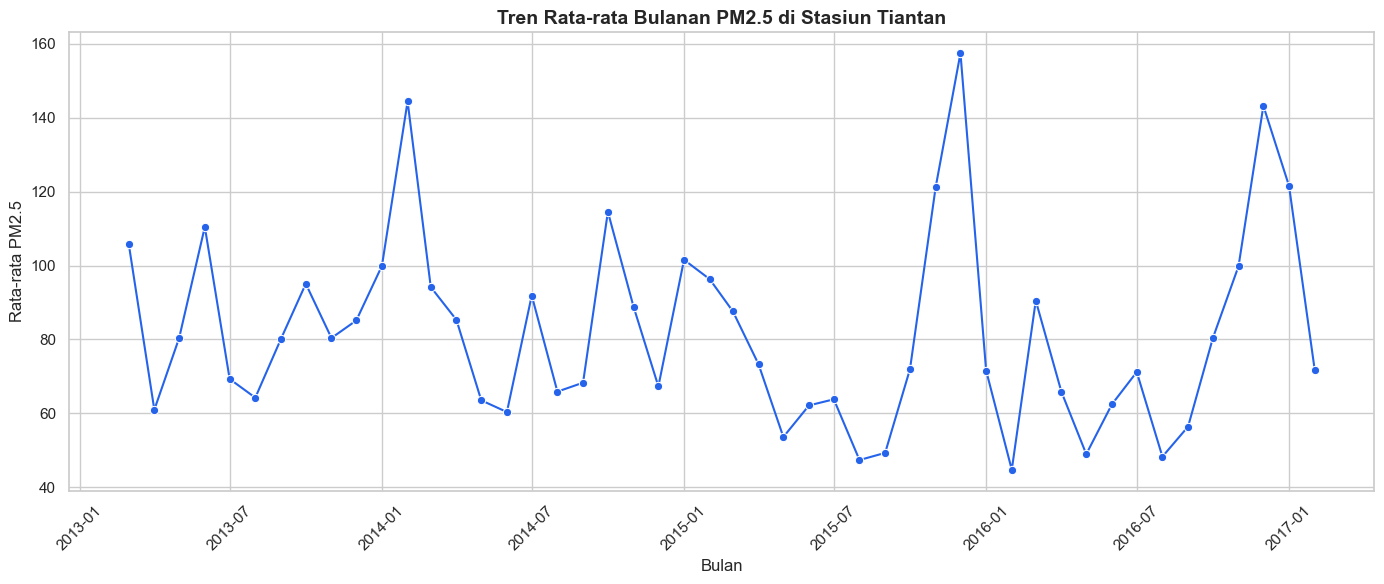

In [19]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_pm25, x="datetime", y="PM2.5", marker="o", color="#2563eb")
plt.title("Tren Rata-rata Bulanan PM2.5 di Stasiun Tiantan", fontsize=14, weight="bold")
plt.xlabel("Bulan")
plt.ylabel("Rata-rata PM2.5")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:**

Grafik menunjukkan bahwa tren PM2.5 bulanan tidak stabil dan mengalami beberapa lonjakan. Lonjakan tertinggi terjadi pada Desember 2015, sehingga pemantauan kualitas udara perlu lebih ketat ketika memasuki periode rawan polusi tinggi.


### Pertanyaan 2: Rata-rata PM2.5 dan PM10 Berdasarkan Musim


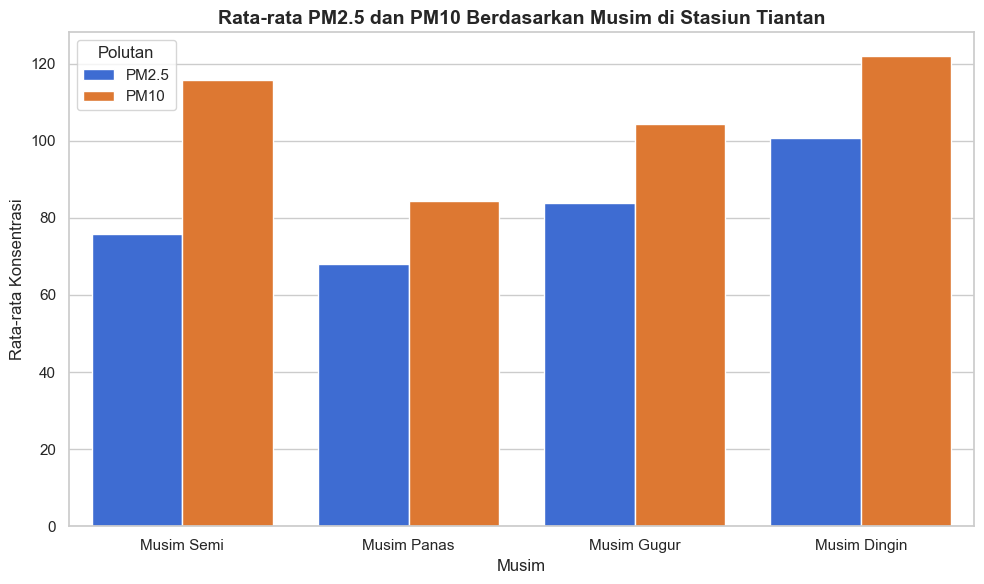

In [20]:
season_pm = (
    season_pollution[["PM2.5", "PM10"]]
    .reset_index()
    .melt(id_vars="season", var_name="Polutan", value_name="Rata-rata")
)

plt.figure(figsize=(10, 6))
sns.barplot(data=season_pm, x="season", y="Rata-rata", hue="Polutan", order=season_order, palette=["#2563eb", "#f97316"])
plt.title("Rata-rata PM2.5 dan PM10 Berdasarkan Musim di Stasiun Tiantan", fontsize=14, weight="bold")
plt.xlabel("Musim")
plt.ylabel("Rata-rata Konsentrasi")
plt.legend(title="Polutan")
plt.tight_layout()
plt.show()


**Insight:**

Musim dingin menjadi musim dengan rata-rata PM2.5 dan PM10 tertinggi. Hal ini menjawab pertanyaan bisnis kedua bahwa risiko polusi partikulat paling tinggi muncul pada musim dingin selama periode data 2013-2017.


### Pertanyaan 3: Heatmap Korelasi Polutan dan Cuaca


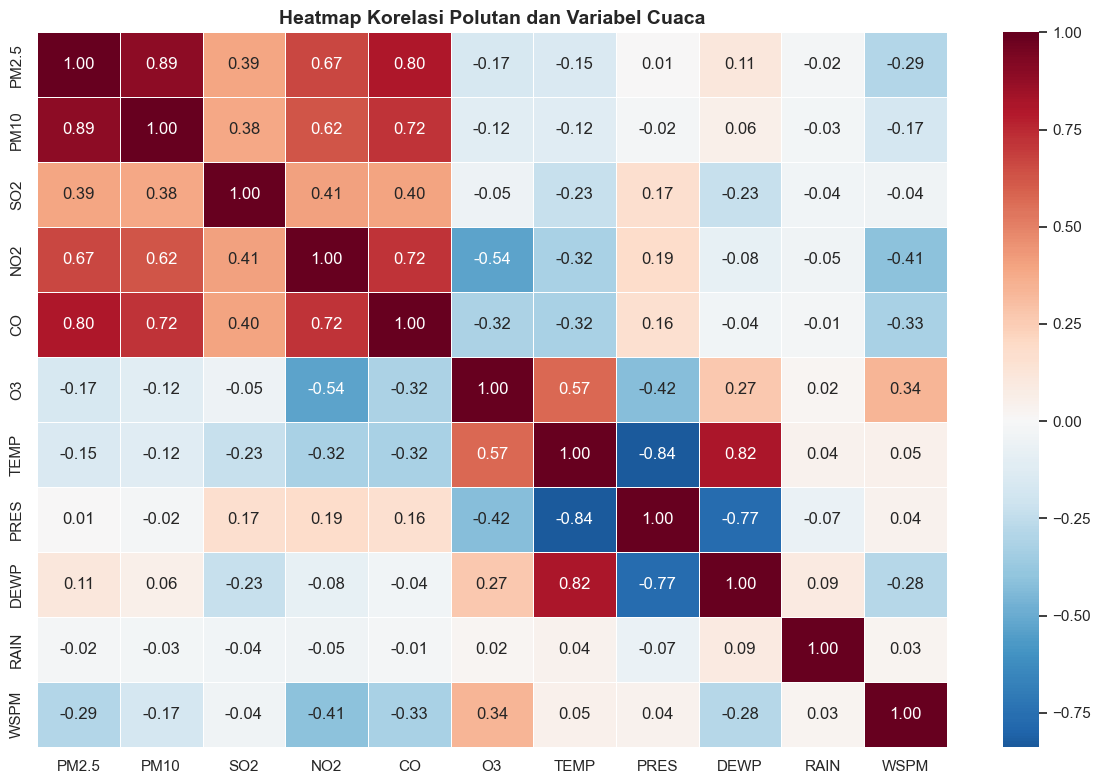

In [21]:
corr_cols = pollutant_cols + weather_cols
corr_matrix = clean_df[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5)
plt.title("Heatmap Korelasi Polutan dan Variabel Cuaca", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()


**Insight:**

PM2.5 berkorelasi kuat dengan PM10 dan juga berkaitan dengan beberapa polutan lain seperti NO2 dan CO. WSPM memiliki korelasi negatif dengan PM2.5, sehingga kondisi angin lebih kencang cenderung berhubungan dengan konsentrasi PM2.5 yang lebih rendah.


### Visualisasi Tambahan: Rata-rata Polutan Utama tanpa CO


C:\Users\restu\AppData\Local\Temp\ipykernel_19952\871901483.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_pollutants_no_co, x="Polutan", y="Rata-rata", palette="viridis")


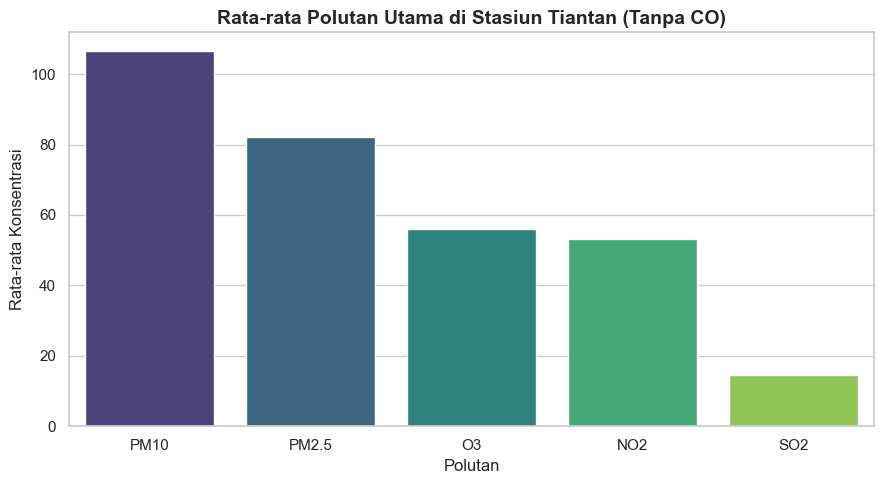

In [22]:
avg_pollutants_no_co = clean_df[["PM2.5", "PM10", "SO2", "NO2", "O3"]].mean().sort_values(ascending=False).reset_index()
avg_pollutants_no_co.columns = ["Polutan", "Rata-rata"]

plt.figure(figsize=(9, 5))
sns.barplot(data=avg_pollutants_no_co, x="Polutan", y="Rata-rata", palette="viridis")
plt.title("Rata-rata Polutan Utama di Stasiun Tiantan (Tanpa CO)", fontsize=14, weight="bold")
plt.xlabel("Polutan")
plt.ylabel("Rata-rata Konsentrasi")
plt.tight_layout()
plt.show()


**Insight:**

CO tidak dimasukkan pada grafik ini karena skalanya jauh lebih besar. Tanpa CO, perbandingan antar polutan utama menjadi lebih mudah dibaca, dan PM10 terlihat sebagai polutan dengan rata-rata tertinggi.


## Analisis Lanjutan

Teknik analisis lanjutan yang digunakan adalah **manual grouping/binning**. Nilai PM2.5 numerik dikelompokkan menjadi kategori tingkat polusi agar hasil analisis lebih mudah dipahami dan dapat digunakan sebagai dasar rekomendasi.


In [23]:
category_order = ["Baik", "Sedang", "Tidak Sehat Ringan", "Tidak Sehat", "Sangat Tidak Sehat"]
pm25_category_count = (
    clean_df["pm25_category"]
    .value_counts()
    .reindex(category_order)
    .reset_index()
)
pm25_category_count.columns = ["Kategori PM2.5", "Jumlah Data"]
pm25_category_count


,Kategori PM2.5,Jumlah Data
0,Baik,12352
1,Sedang,8529
2,Tidak Sehat Ringan,5688
3,Tidak Sehat,2952
4,Sangat Tidak Sehat,5543


C:\Users\restu\AppData\Local\Temp\ipykernel_19952\80585436.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pm25_category_count, x="Kategori PM2.5", y="Jumlah Data", order=category_order, palette="rocket")


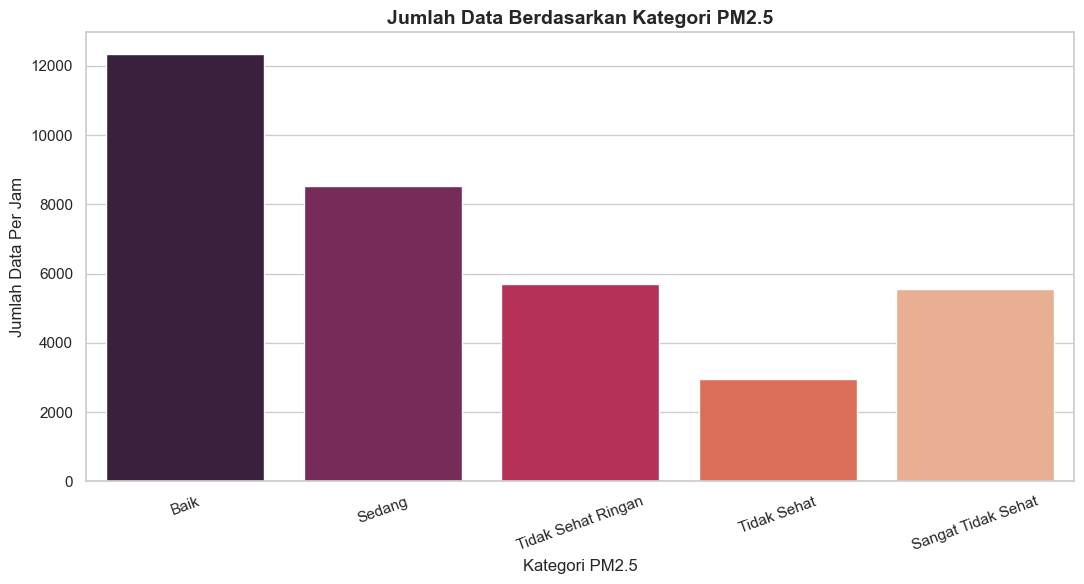

In [24]:
plt.figure(figsize=(11, 6))
sns.barplot(data=pm25_category_count, x="Kategori PM2.5", y="Jumlah Data", order=category_order, palette="rocket")
plt.title("Jumlah Data Berdasarkan Kategori PM2.5", fontsize=14, weight="bold")
plt.xlabel("Kategori PM2.5")
plt.ylabel("Jumlah Data Per Jam")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Insight:**

Kategori `Baik` memiliki jumlah data paling banyak, tetapi kategori `Tidak Sehat`, `Tidak Sehat Ringan`, dan `Sangat Tidak Sehat` juga muncul dalam jumlah signifikan. Artinya, meskipun banyak periode berada pada kondisi lebih aman, Stasiun Tiantan tetap mengalami banyak jam dengan risiko kualitas udara yang perlu diperhatikan.


## Conclusion


- **Pertanyaan 1:** Tren rata-rata bulanan PM2.5 di Stasiun Tiantan selama Maret 2013 hingga Februari 2017 berfluktuasi. Nilai rata-rata bulanan tertinggi terjadi pada Desember 2015 sekitar 157,46, sedangkan nilai terendah terjadi pada Februari 2016 sekitar 44,74.
- **Pertanyaan 2:** Musim dingin merupakan musim dengan tingkat polusi partikulat tertinggi. Rata-rata PM2.5 pada musim dingin sekitar 100,63 dan rata-rata PM10 sekitar 122,04, lebih tinggi dibandingkan musim lain.
- **Pertanyaan 3:** Kecepatan angin (`WSPM`) memiliki hubungan negatif dengan PM2.5. Korelasi sekitar -0,292 menunjukkan bahwa konsentrasi PM2.5 cenderung lebih rendah ketika kecepatan angin meningkat.


## Recommendation / Action Item


1. Pemantauan kualitas udara perlu ditingkatkan pada musim dingin karena musim ini memiliki rata-rata PM2.5 dan PM10 paling tinggi.
2. Peringatan kualitas udara sebaiknya lebih sering diberikan ketika PM2.5 masuk kategori `Tidak Sehat` atau `Sangat Tidak Sehat`.
3. Hasil kategori PM2.5 dapat digunakan sebagai dasar sistem peringatan dini sederhana untuk membantu masyarakat mengurangi aktivitas luar ruangan saat kualitas udara memburuk.
4. Analisis dapat diperbarui secara berkala apabila tersedia data baru agar pola musiman dan episode polusi tinggi tetap terpantau.
